# <center> A <center>

(([], []), ([], []))

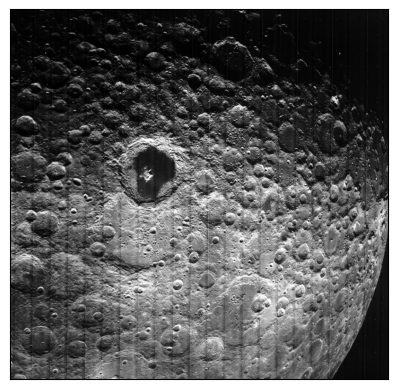

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

'''
Load the Image, space.jpg, and plot it using imshow()
'''

# Load the image
image = cv2.imread('Space1.png', cv2.IMREAD_GRAYSCALE)

# Display the image
plt.imshow(image, cmap='gray')
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis

# <center> B <center>

(([], []), ([], []))

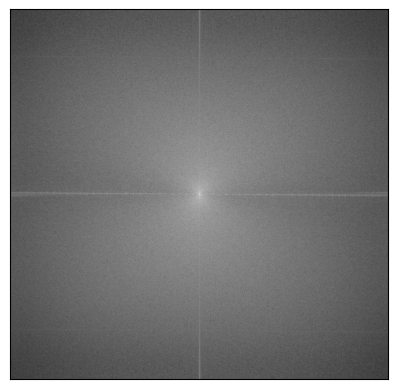

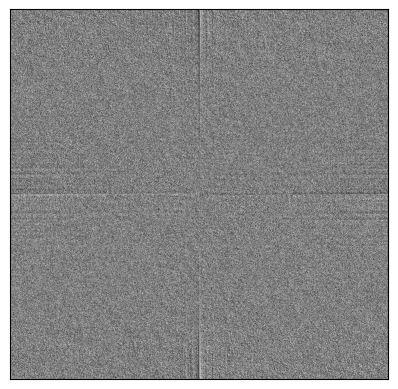

In [46]:
'''
Perform the 2D Discrete Fourier transform of the image and plot the amplitude and phase information.
You may need to use fftshift() to rearrange the quadrants of the fft result
'''

# Perform the 2D Discrete Fourier transform
f = np.fft.fft2(image)
f1 = np.fft.fftshift(f)
f2 = np.abs(f1)
f3 = np.log(f2 + 1)

fa = np.angle(f)

# Plot the amplitude and phase information
plt.figure()
plt.imshow(f3, cmap='gray')
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis

plt.figure()
plt.imshow(np.fft.fftshift(fa), cmap='gray')
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis




# <center> C <center>
If we zoom in in a particular area where we have the x-axis visible, we will notice several straight vertical lines. These are what causes the original image to have vertical straight black lines.

# <center> D <center>

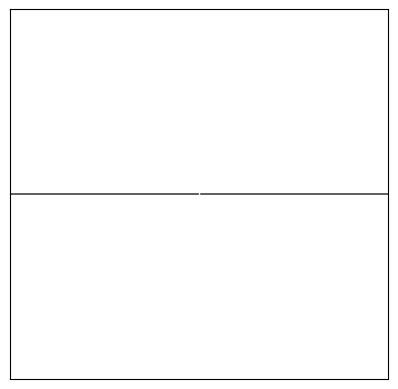

([], [])

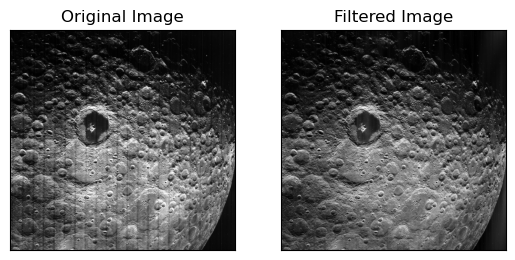

In [47]:
'''
Make a filter to get rid of the line impulses. Plot the filter design and discuss on why such a design
was chosen. Implement the filter in frequency domain
'''

# Make a filter to get rid of the line impulses
rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

# Create a mask first, center square is 1, remaining all zeros
mask = np.ones((rows, cols), np.uint8)
value_row = 2
value_col = 2
mask[crow - value_row:crow + value_row, :ccol-value_col] = 0
mask[crow - value_row:crow + value_row, ccol+value_col:] = 0

# Create a Gaussian filter
fshift = f1 * mask
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)

# Plot the filter design
plt.figure()
plt.imshow(mask, cmap='gray')
plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis
plt.show()

# plt.figure()
# plt.imshow(fshift, cmap='gray')
# plt.xticks([]), plt.yticks([])  # to hide tick values on X and Y axis

ax1 = plt.subplot(1, 2, 1)
ax1.imshow(image, cmap='gray')
ax1.set_title('Original Image')
ax1.set_xticks([]), ax1.set_yticks([])  # to hide tick values on X and Y axis

# Plot the filter design
ax2 = plt.subplot(1, 2, 2)
ax2.imshow(np.abs(img_back), cmap='gray')
ax2.set_title('Filtered Image')
ax2.set_xticks([]), ax2.set_yticks([])  # to hide tick values on X and Y axis


# <center> E <center>
Reconstruct the image using inverse Fourier transforms. Comment on the effect of the size of the filter
on the output image. Are you able to satisfactorily remove the undesired artifacts from the image?

The reconstructed image is shown above. I have managed to accomplish the removal of the lines excellently. By changing the values of "value_row" and "value_col" we can also find better values. By increasing the values we decrease the visibility of the lines, but we also decrease the quality of our picture.

# <center> F <center>

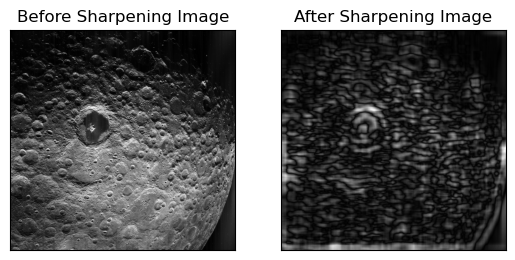

In [48]:
'''
[Image enhancement - Spatial Domain Filtering] Finally, using information from the class, apply a
sharpening filter to increase the sharpness of the image. Recall that this filter is obtained by first blurring
the image, and adding to the original image the image without blur, i.e.
Sharp = I + (I - blur)
You may choose the type of blur you make, using either the averaging filter, or the gaussian kernal
and convolve with the original image. You may need to play around with the individual kernals used to
implement sharpening. Comment on what you observe.
'''

from scipy.signal import convolve2d
N = 50
filt = 1/(N**2) * np.ones((N, N))

# Apply the filter
blurred = convolve2d(img_back, filt, mode='same')
sharp = blurred - (convolve2d(blurred, filt, mode='same'))

# Plot the sharpened image
ax1 = plt.subplot(1, 2, 1)
ax1.imshow(np.abs(img_back), cmap='gray')
ax1.set_title('Before Sharpening Image')
ax1.set_xticks([]), ax1.set_yticks([])  # to hide tick values on X and Y axis

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(np.abs(sharp), cmap='gray')
ax2.set_title('After Sharpening Image')
ax2.set_xticks([]), ax2.set_yticks([])  # to hide tick values on X and Y axis
plt.show()